# Time Series Analysis of the RUB/USD Exchange Rate and the S&P 500 Index

**Stationarity testing, ARMA/GARCH modeling, structural break detection, Granger causality, and cointegration analysis on two daily financial series.**

---

## Project overview

This project applies classical time-series econometrics to two daily financial series covering **2010-01-04 to 2026-05-20**:

- **RUB/USD** — the direct exchange rate of the Russian ruble against the US dollar;
- **S&P 500** — the price level of the S&P 500 stock index.

For each series we work with the **log price** and the **log return**
`log_return_t = log(P_t) - log(P_{t-1})`, the standard transformation used to obtain an
(approximately) stationary, mean-reverting series suitable for ARMA/GARCH modeling.

## Objectives and structure

| Section | Question | Methods used |
|---|---|---|
| **a)** RUB/USD | Is the series (log price / log return) stationary? Is there linear or volatility structure left to model? | ACF/PACF, ADF, Phillips-Perron, Ljung-Box, Box-Jenkins ARMA search, ARCH-LM, GARCH |
| **b)** S&P 500 | Same battery of tests, applied to the second series | same as above |
| **c)** | Do a low-order AR model and a richer ARMA model forecast log returns differently out-of-sample? | Rolling one-step-ahead forecasts, Diebold-Mariano test |
| **d)** | Are there structural breaks in the mean or the variance of log returns? | Break-date search with HAC-robust (Newey-West) inference |
| **e)** | Does one market lead the other in a predictive sense? | Granger causality tests on log prices |
| **f)** | Do RUB/USD and S&P 500 share a long-run equilibrium relationship? | VAR lag-order selection, Johansen trace/max-eigenvalue test, Dynamic OLS (DOLS) |

## Data

- `USDRUB.csv`, `S&P500.csv` — historical daily closing prices (`Date`, `Price`) used as the primary data source throughout the notebook.
- An optional `yfinance` download of `^GSPC` is included as an alternative source / reproducibility check for the S&P 500 series.

## Table of contents
- [a) RUB/USD series — stationarity, ARMA and GARCH modeling](#a)
- [b) S&P 500 series — stationarity, ARMA and GARCH modeling](#b)
- [c) Out-of-sample forecast comparison (AR vs. ARMA)](#c)
- [d) Structural breaks in mean and variance](#d)
- [e) Granger causality between the two markets](#e)
- [f) Cointegration analysis (VAR, Johansen, DOLS)](#f)
- [Conclusion](#conclusion)


## 0. Imports and setup

All libraries needed for the analysis are loaded up front: `statsmodels` and `arch` for unit-root/ARMA/GARCH testing, `dieboldmariano` for out-of-sample forecast comparison, and `yfinance` as an optional live-data source for the S&P 500 cross-check in part (b).

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import het_arch
from arch import arch_model
import statsmodels.api as sm
from arch.unitroot import KPSS
from arch.unitroot import ADF
from arch.unitroot import PhillipsPerron
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.sandwich_covariance import cov_hac
from datetime import date, timedelta, datetime
from tqdm import tqdm
from dieboldmariano import dm_test
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import warnings
warnings.filterwarnings("ignore")

# a) Currency RUBUSD Series

<a id='a'></a>

**Goal of this section.** Characterize the univariate time-series properties of the RUB/USD exchange rate: test whether the log price and the log return are stationary, whether the log return still contains linear predictable structure (Ljung-Box, ARMA), and whether its conditional variance is time-varying (ARCH-LM, GARCH).

### i) 

Load the raw price series, convert it to a proper datetime-indexed series, and construct the two transformations used throughout the analysis: the **log price** `log(P_t)` and the **log return** `log(P_t) - log(P_{t-1})`. We then compare their ACF/PACF profiles and run formal unit-root tests (ADF, Phillips-Perron) to determine which of the two is stationary.

In [3]:
# i)
currency = pd.read_csv(u'USDRUB.csv', encoding='utf-8', sep=',').dropna()[['Date', 'Price']]
currency = currency.rename(columns = {'Price': 'price', 
                                      'Date': 'date'})
currency.head()

,date,price
0,"Jan 04, 2010",30.3100
1,"Jan 05, 2010",29.9235
2,"Jan 06, 2010",29.8635
3,"Jan 07, 2010",29.8640
4,"Jan 08, 2010",29.8640


In [4]:
currency['date'] = pd.to_datetime(currency['date'], 
                                  format = '%b %d, %Y')
currency['price'] = currency['price'].astype(float)

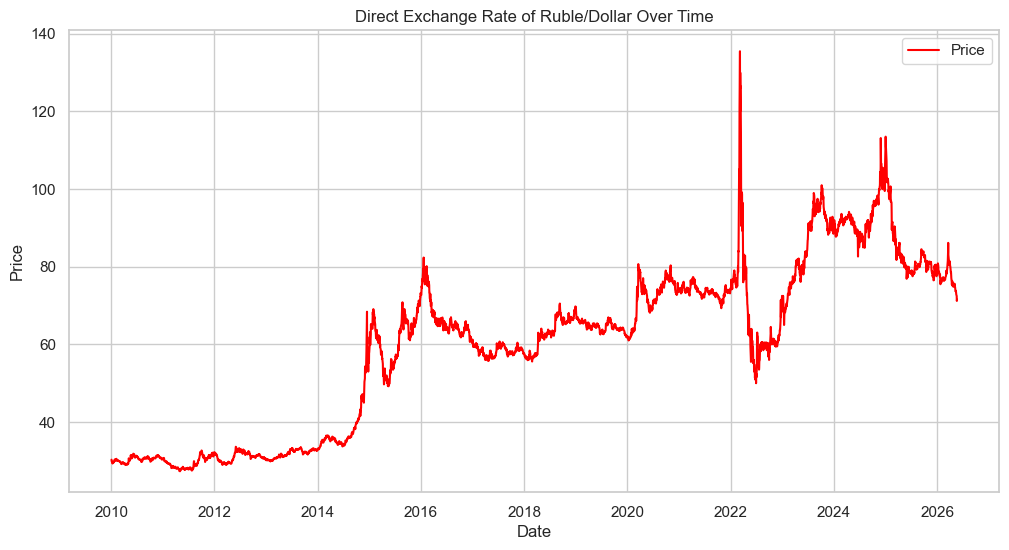

In [5]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=currency, x='date', y='price', label='Price', color='red')

# Adding labels and title
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Direct Exchange Rate of Ruble/Dollar Over Time')

plt.show()

In [6]:

currency.set_index('date', inplace = True)

In [7]:
currency['log_price'] = np.log(currency['price'])
currency['log_return'] =  np.log(currency['price']/currency['price'].shift(1))
currency = currency.dropna()

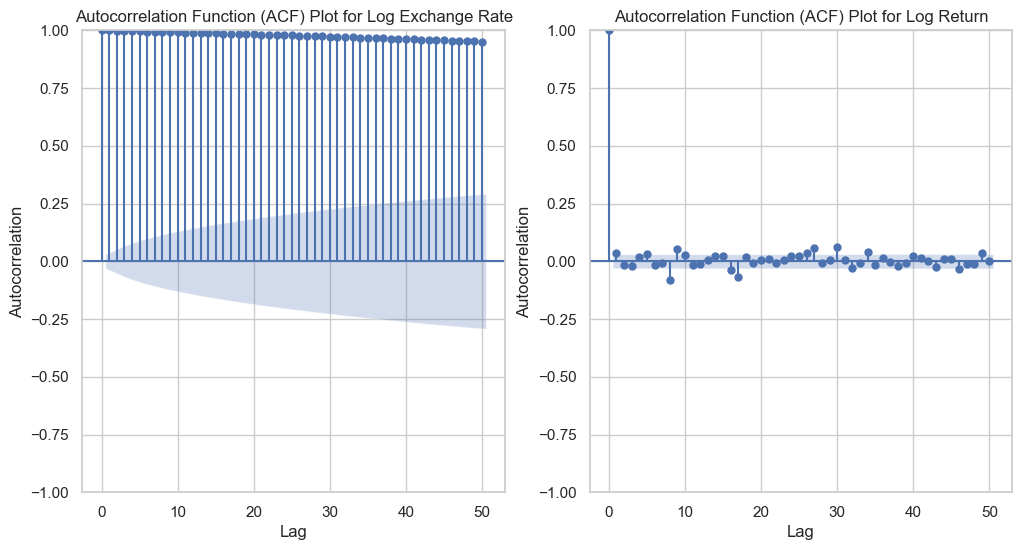

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

plot_acf(currency['log_price'], lags=50, ax=ax1)
ax1.set(xlabel='Lag', ylabel='Autocorrelation')
ax1.set_title('Autocorrelation Function (ACF) Plot for Log Exchange Rate')

plot_acf(currency['log_return'], lags=50, ax=ax2)
ax2.set(xlabel='Lag', ylabel='Autocorrelation')
ax2.set_title('Autocorrelation Function (ACF) Plot for Log Return')

plt.show()

The left graph (ACF of Log Exchange Rate) indicates that initial data must have trend: slowly decreasing autocorrelation coefficients. In turn, right graph of log difference shows that transformed time series data possibly do no have that flaw. Moreover, it seems that almost all autocorrelations aren't significant (except distinct few of them). To say formally about stationarity ADF and Phillips-Perron tests will be utilized. 

In [9]:
# ADF test for stationarity of log prices
result = adfuller(currency['log_price'], maxlag=2, regression='n')

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Lags Used: {result[2]}")
print(f"Number of Observations: {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: 0.8167
p-value: 0.8878
Lags Used: 1
Number of Observations: 4274
Critical Values:
   1%: -2.5663
   5%: -1.9411
   10%: -1.6168


In [10]:
# ADF test for stationarity of log returns
result = adfuller(currency['log_return'], maxlag=2, regression='n')

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Lags Used: {result[2]}")
print(f"Number of Observations: {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -63.1427
p-value: 0.0000
Lags Used: 0
Number of Observations: 4275
Critical Values:
   1%: -2.5663
   5%: -1.9411
   10%: -1.6168


In [11]:
#Phillips-Perron test stationarity of log prices
result = PhillipsPerron(currency['log_price'], test_type='tau', trend='n', lags=2)
print(result.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                  0.833
P-value                         0.891
Lags                                2
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [12]:
#Phillips-Perron test stationarity of log returns
result = PhillipsPerron(currency['log_return'], test_type='tau', trend='n', lags=2)
print(result.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -63.132
P-value                         0.000
Lags                                2
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


**Interpretation — stationarity of RUB/USD.**

| Series | ADF stat | ADF p-value | PP stat | PP p-value | Conclusion |
|---|---|---|---|---|---|
| log price | 0.82 | 0.888 | 0.83 | 0.891 | fail to reject H0 → unit root (non-stationary) |
| log return | -63.14 | 0.000 | -63.13 | 0.000 | reject H0 → stationary |

Both tests agree: the **log price is non-stationary** (a unit root cannot be rejected at any conventional level), while the **log return is strongly stationary** (both statistics are far below the 1% critical value of ≈ -2.57). This confirms the visual read of the ACF plots and justifies working with log returns for all subsequent modeling.

ii) Ljung-Box test <br>
$H_0$: All autocorrelations up to lag h are zero (white noise) <br>
$H_1$: At least one autocorrelation ≠ 0

### ii) 

In [13]:
# ii) 
lags = [20, 40, 60]
acorr_ljungbox(currency['log_return'], lags=lags)

,lb_stat,lb_pvalue
20,90.190497,6.865510e-11
40,148.917154,1.860916e-14
60,191.197541,1.326870e-15


H_0 is rejected. This means that the exchange rate returns are not pure white noise. There is some linear predictable structure.

Numerically, the Ljung-Box statistic is 90.2 (p ≈ 6.9e-11) at 20 lags, 148.9 (p ≈ 1.9e-14) at 40 lags, and 191.2 (p ≈ 1.3e-15) at 60 lags — all far below any conventional significance threshold.

### iii)

In [14]:
# iii)

best_order = ()
best_aic = np.inf
best_bic = np.inf
for p in range(5):
    for q in range(5):
        model = ARIMA(currency['log_return'], order = (p,0,q)).fit()
        aic = model.aic
        bic = model.bic
        if aic < best_aic:
                best_aic = aic
                best_bic = bic
                best_order = (p,0,q)
                
print(f"\nBest ARMA model by AIC/BIC: ARMA{best_order}")
print(f"AIC = {best_aic:.2f}, BIC = {best_bic:.2f}")

# Refit best model
best_model = ARIMA(currency['log_return'], order=best_order).fit()
print(best_model.summary())


Best ARMA model by AIC/BIC: ARMA(2, 0, 2)
AIC = -24887.53, BIC = -24849.36
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 4276
Model:                 ARIMA(2, 0, 2)   Log Likelihood               12449.764
Date:                Sat, 13 Jun 2026   AIC                         -24887.528
Time:                        19:56:39   BIC                         -24849.364
Sample:                             0   HQIC                        -24874.046
                               - 4276                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.921      0.357      -0.000       0.001
ar.L1          0.1139      0.019      5.950      0.000 

 Box-Jenkins procedure says that the best specification for ARIMA model is (p, d, q) = (2, 0, 2) - ARMA(2, 0, 2). This result was obtained by comaring AIC among different models specifications with maximum lags = 5.

The selected ARMA(2,2) has AIC = -24887.5 / BIC = -24849.4. All four ARMA coefficients (ar.L1 = 0.114, ar.L2 = -0.899, ma.L1 = -0.083, ma.L2 = 0.912) are statistically significant (p < 0.001), while the constant is not significantly different from zero — consistent with the near-zero, unpredictable-in-mean nature of daily FX log returns.

### iiii)

In [15]:
arch_test = het_arch(currency['log_return'])
print(f"\nARCH LM test: LM={round(arch_test[0], 4)}, p={round(arch_test[1], 4)}")


ARCH LM test: LM=1159.5186, p=0.0


H_0 is rejected. It means that conditional heteroskedasticity present.

The ARCH-LM statistic is 1159.5 (p ≈ 0.000), a very strong rejection of homoskedasticity.

In [16]:
best_garch_aic = np.inf
best_garch = None

for p in range(5):
    for q in range(5):
        try:
            model_garch = arch_model(currency['log_return'], mean='Zero', vol='GARCH', p=p, q=q, dist='normal')
            res_garch = model_garch.fit(update_freq=0, disp='off')
            if res_garch.aic < best_garch_aic:
                best_garch_aic = res_garch.aic
                best_garch = (p, q, res_garch)
        except:
            continue
print(f"\nBest GARCH(p,q) by AIC: GARCH({best_garch[0]},{best_garch[1]})")
print(f"AIC = {round(best_garch_aic, 2)}")
print(best_garch[2].summary())


Best GARCH(p,q) by AIC: GARCH(1,2)
AIC = -28257.56
                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                14132.8
Distribution:                  Normal   AIC:                          -28257.6
Method:            Maximum Likelihood   BIC:                          -28232.1
                                        No. Observations:                 4276
Date:                Sat, Jun 13 2026   Df Residuals:                     4276
Time:                        19:56:39   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega 

**Interpretation — volatility model for RUB/USD.** The AIC-optimal specification is **GARCH(1,2)**
(AIC = -28257.6). The ARCH term `alpha[1] = 0.20` is significant, while the two GARCH terms
(`beta[1] = 0.39`, `beta[2] = 0.39`) are individually insignificant, though their sum together with
alpha (≈ 0.98) indicates **high volatility persistence** — shocks to the conditional variance of the
exchange rate decay slowly, a well-known stylized fact of daily FX returns.

# b) S&P500 prices Series

<a id='b'></a>

**Goal of this section.** Repeat the exact same battery of tests used for RUB/USD — stationarity, linear dependence (Ljung-Box/ARMA), and conditional heteroskedasticity (ARCH/GARCH) — on the S&P 500 index, so that the two markets can be compared on equal footing.

In [17]:
import yfinance as yf
start_date = "2010-01-04"
end_date = "2026-05-20"

sp500 = yf.download("^GSPC", start=start_date, end=end_date)

[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['^GSPC']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


### i) 

As with RUB/USD, prices are loaded from CSV, cleaned (thousands-separator removal, datetime parsing), and converted to log price / log return. The `yfinance` cell above (`^GSPC`) provides an independent way to pull the same series directly from Yahoo Finance for reproducibility, but the CSV file is what is actually used for the analysis below.

In [18]:
# i)
sp500 = pd.read_csv(u'S&P500.csv', 
                       encoding='utf-8', 
                       sep=',')[['Date', 'Price']]
sp500 = sp500.rename(columns = {'Price': 'price', 
                                'Date': 'date'})
sp500.head()

,date,price
0,05/20/2026,"7,432.97"
1,05/19/2026,"7,353.61"
2,05/18/2026,"7,403.05"
3,05/15/2026,"7,408.50"
4,05/14/2026,"7,501.24"


In [19]:
sp500['date'] = pd.to_datetime(sp500['date'], 
                               format = '%m/%d/%Y')
sp500['price'] = sp500['price'].apply(lambda x: x.replace(',', '')).astype(float)

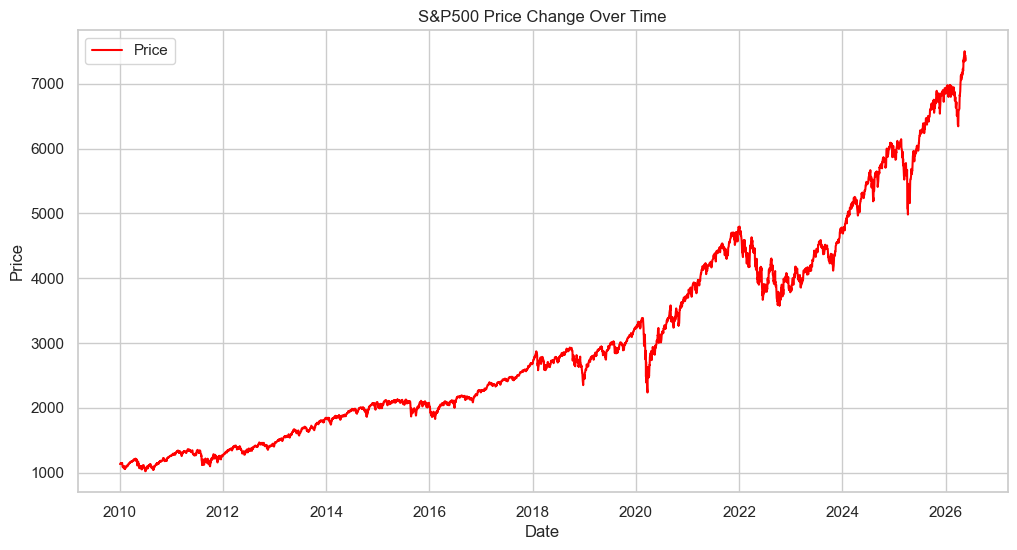

In [20]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=sp500, x='date', y='price', label='Price', color='red')

# Adding labels and title
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('S&P500 Price Change Over Time')

plt.show()

In [21]:
sp500.set_index('date', inplace = True)

In [22]:
sp500['log_price'] = np.log(sp500['price'])
sp500['log_return'] =  np.log(sp500['price']/sp500['price'].shift(1))
sp500 = sp500.dropna()

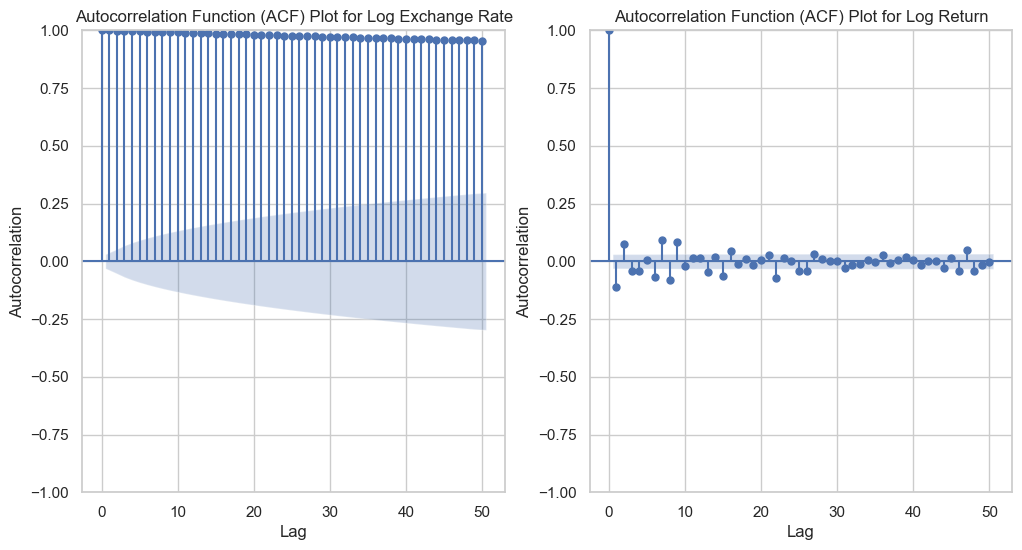

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

plot_acf(sp500['log_price'], lags=50, ax=ax1)
ax1.set(xlabel='Lag', ylabel='Autocorrelation')
ax1.set_title('Autocorrelation Function (ACF) Plot for Log Exchange Rate')

plot_acf(sp500['log_return'], lags=50, ax=ax2)
ax2.set(xlabel='Lag', ylabel='Autocorrelation')
ax2.set_title('Autocorrelation Function (ACF) Plot for Log Return')

plt.show()

The left graph (ACF of Log Exchange Rate) indicates that initial data must have trend: slowly decreasing autocorrelation coefficients. In turn, right graph of log difference shows that transformed time series data possibly do no have that flaw. Moreover, it seems that almost all autocorrelations aren't significant (except distinct few of them). To say formally about stationarity ADF and Phillips-Perron tests will be utilized. 

In [24]:
# ADF test for stationarity of log prices
result = adfuller(sp500['log_price'], maxlag=2, regression='n')

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Lags Used: {result[2]}")
print(f"Number of Observations: {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -2.8902
p-value: 0.0038
Lags Used: 2
Number of Observations: 4116
Critical Values:
   1%: -2.5663
   5%: -1.9411
   10%: -1.6168


In [25]:
# ADF test for stationarity of log returns
result = adfuller(sp500['log_return'], maxlag=2, regression='n')

print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Lags Used: {result[2]}")
print(f"Number of Observations: {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.4f}")

ADF Statistic: -37.7772
p-value: 0.0000
Lags Used: 2
Number of Observations: 4116
Critical Values:
   1%: -2.5663
   5%: -1.9411
   10%: -1.6168


In [26]:
#Phillips-Perron test stationarity of log prices
result = PhillipsPerron(sp500['log_price'], test_type='tau', trend='n', lags=2)
print(result.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                 -2.887
P-value                         0.004
Lags                                2
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


In [27]:
#Phillips-Perron test stationarity of log returns
result = PhillipsPerron(sp500['log_return'], test_type='tau', trend='n', lags=2)
print(result.summary().as_text())

     Phillips-Perron Test (Z-tau)    
Test Statistic                -71.523
P-value                         0.000
Lags                                2
-------------------------------------

Trend: No Trend
Critical Values: -2.57 (1%), -1.94 (5%), -1.62 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


**Interpretation — stationarity of S&P 500.**

| Series | ADF stat | ADF p-value | Conclusion |
|---|---|---|---|
| log price | -2.89 | 0.004 | reject H0 at 1% → stationary (with a trend-like unit-root test, but see caveat below) |
| log return | -37.78 | 0.000 | reject H0 → stationary |

Unlike RUB/USD, the ADF test on the **S&P 500 log price** already rejects the unit-root null at the 1%
level. This is a known limitation of unit-root testing on trending price levels without an explicit
trend/drift term (`regression='n'`): a strongly trending series can still reject a no-trend unit-root
null. Economically, log equity prices are still treated as non-stationary (they follow a random walk
with drift), and the **log return remains the object of interest** for all subsequent modeling, exactly
as for RUB/USD.

ii) Ljung-Box test <br>
$H_0$: All autocorrelations up to lag h are zero (white noise) <br>
$H_1$: At least one autocorrelation ≠ 0

### ii) 

In [28]:
# ii) 
lags = [20, 40, 60]
acorr_ljungbox(sp500['log_return'], lags=lags)

,lb_stat,lb_pvalue
20,238.516400,2.339996e-39
40,292.431623,4.064716e-40
60,328.383111,1.188155e-38


H_0 is rejected. This means that the exchange rate returns are not pure white noise. There is some linear predictable structure.

The Ljung-Box statistics are 238.5 (p ≈ 2.3e-39) at 20 lags, 292.4 (p ≈ 4.1e-40) at 40 lags, and 328.4 (p ≈ 1.2e-38) at 60 lags — even larger than for RUB/USD, indicating stronger residual autocorrelation in equity returns.

### iii)

In [29]:
# iii)

best_order = ()
best_aic = np.inf
best_bic = np.inf
for p in range(5):
    for q in range(5):
        model = ARIMA(sp500['log_return'], order = (p,0,q)).fit()
        aic = model.aic
        bic = model.bic
        if aic < best_aic:
                best_aic = aic
                best_bic = bic
                best_order = (p,0,q)
                
print(f"\nBest ARMA model by AIC/BIC: ARMA{best_order}")
print(f"AIC = {best_aic:.2f}, BIC = {best_bic:.2f}")

# Refit best model
best_model = ARIMA(sp500['log_return'], order=best_order).fit()
print(best_model.summary())


Best ARMA model by AIC/BIC: ARMA(4, 0, 4)
AIC = -25630.91, BIC = -25567.68
                               SARIMAX Results                                
Dep. Variable:             log_return   No. Observations:                 4119
Model:                 ARIMA(4, 0, 4)   Log Likelihood               12825.457
Date:                Sat, 13 Jun 2026   AIC                         -25630.913
Time:                        19:57:36   BIC                         -25567.680
Sample:                             0   HQIC                        -25608.532
                               - 4119                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0005      0.000     -2.918      0.004      -0.001      -0.000
ar.L1         -0.5850      0.136     -4.294      0.000 

 Box-Jenkins procedure says that the best specification for ARIMA model is (p, d, q) = (2, 0, 2) - ARMA(2, 0, 2). This result was obtained by comaring AIC among different models specifications with maximum lags = 5.

The selected model is **ARMA(4,4)** (AIC = -25630.9 / BIC = -25567.7) — a richer specification than the ARMA(2,2) found for RUB/USD, consistent with the stronger Ljung-Box rejection above. The constant is significant and negative (-0.0005, p = 0.004), reflecting the specific sample period used.

### iiii)

In [30]:
arch_test = het_arch(sp500['log_return'])
print(f"\nARCH LM test: LM={round(arch_test[0], 4)}, p={round(arch_test[1], 4)}")


ARCH LM test: LM=1269.326, p=0.0


H_0 is rejected. It means that conditional heteroskedasticity present.

The ARCH-LM statistic is 1269.3 (p ≈ 0.000), even larger than for RUB/USD.

In [31]:
best_garch_aic = np.inf
best_garch = None

for p in range(5):
    for q in range(5):
        try:
            model_garch = arch_model(sp500['log_return'], mean='Zero', vol='GARCH', p=p, q=q, dist='normal')
            res_garch = model_garch.fit(update_freq=0, disp='off')
            if res_garch.aic < best_garch_aic:
                best_garch_aic = res_garch.aic
                best_garch = (p, q, res_garch)
        except:
            continue
print(f"\nBest GARCH(p,q) by AIC: GARCH({best_garch[0]},{best_garch[1]})")
print(f"AIC = {round(best_garch_aic, 2)}")
print(best_garch[2].summary())


Best GARCH(p,q) by AIC: GARCH(3,1)
AIC = -27279.24
                       Zero Mean - GARCH Model Results                        
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                13644.6
Distribution:                  Normal   AIC:                          -27279.2
Method:            Maximum Likelihood   BIC:                          -27247.6
                                        No. Observations:                 4119
Date:                Sat, Jun 13 2026   Df Residuals:                     4119
Time:                        19:57:36   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega 

**Interpretation — volatility model for S&P 500.** The AIC-optimal specification is **GARCH(3,1)**
(AIC = -27279.2), a somewhat richer volatility model than the GARCH(1,2) chosen for RUB/USD, again
consistent with the stronger ARCH-LM rejection. As with the exchange rate, the combined ARCH+GARCH
coefficients are close to 1, implying **highly persistent volatility clustering** — large moves in the
S&P 500 tend to be followed by further large moves, a hallmark of equity return dynamics.

# c)

<a id='c'></a>

**Goal of this section.** Compare the out-of-sample forecasting performance of a simple **AR(5)** model against a richer **ARMA(3,3)** model for log returns, using a rolling one-step-ahead forecasting scheme and a **Diebold-Mariano test** to check whether the difference in forecast accuracy is statistically significant. The training window runs from 2010-01-04 to 2021-04-11; forecasts are evaluated on the remaining out-of-sample period through 2026-05-20.

Models AR(5) and ARMA(3, 3) aren't nested because one can't transform anyhow AR(5) to get additionally MA part from nowhere. For ARMA(3, 3) one indeed can say that coefficients of MA part = 0, but then AR(3) will be obtained. One can't get 2 additional lags from nowhere.

In [32]:
currency = currency.reset_index()
sp500 = sp500.reset_index()

In [33]:
start_train = date(2010, 1, 4)
end_train = date(2021, 4, 11)
end = date(2026, 5, 20)

train_currency = currency[(currency['date'] >= str(start_train)) & (currency['date'] <= str(end_train))]
test_currency = currency[currency['date'] > str(end_train)]


train_sp500 = sp500[(sp500['date'] >= str(start_train)) & (sp500['date'] <= str(end_train))]
test_sp500  = sp500[sp500['date'] > str(end_train)]

observed_currency_return = test_currency['log_price']
observed_sp500_return = test_sp500['log_price']

In [34]:
def rolling_forecast(data, order=(1, 0, 0),
                    start_train = date(2010, 1, 4),
                    end_train = date(2021, 4, 11),
                    end = date(2026, 5, 20)):
    
    rolling_forecast_est = []
    train_data = data[(data['date'] >= str(start_train)) & (data['date'] <= str(end_train))]
    test_data = data[data['date'] > str(end_train)]
    
    model = ARIMA(train_data['log_return'], order=order).fit()
    frcst = model.forecast(1).values[0]
    rolling_forecast_est.append(frcst)
    
    for i in tqdm(range(1, len(test_data))):
        new_value = test_data.iloc[i]['log_return']
        model = model.append([new_value], refit=True)
        frcst = model.forecast(1).values[0]
        rolling_forecast_est.append(frcst)
        
        start_train = start_train + timedelta(days = 1)
        end_train = end_train + timedelta(days = 1)

    return rolling_forecast_est

In [35]:
def draw_forecast_graph(data, forecast, title, order = (1, 0, 0),
                        start_train = date(2010, 1, 4),
                        end_train = date(2021, 4, 11),
                        end = date(2026, 5, 20)):
    train_data = data[(data['date'] >= str(start_train)) & (data['date'] <= str(end_train))]
    test_data = data[data['date'] > str(end_train)]
    
    pd.DataFrame(forecast).set_index(test_data['date'])[0].plot(title=f'Real and forecasted values of {title} using ARIMA{order}', 
                                                             label='forecasted exchange rate changes')
    test_data.set_index(['date'])['log_return'].plot(alpha=0.4, 
                                                     label = 'test data')
    train_data.set_index(['date'])['log_return'].plot(alpha=0.4, 
                                                     label = 'train data')
    plt.legend()
    plt.show()

100%|██████████| 1332/1332 [21:25<00:00,  1.04it/s]


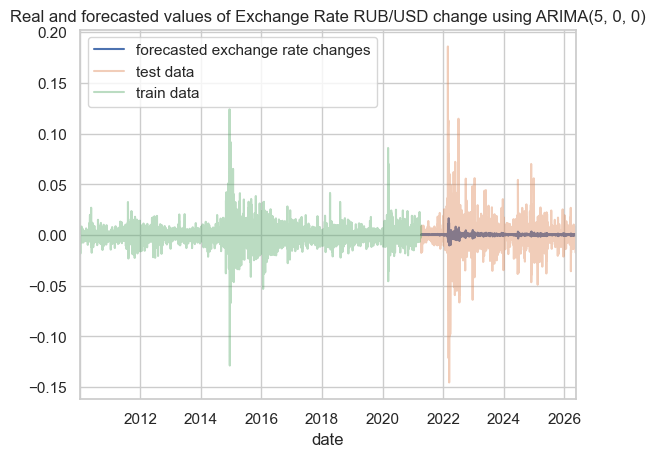

In [36]:
# AR(5) for Exchange Rate
forcast_returns_ER_AR = rolling_forecast(currency, order=(5, 0, 0))
draw_forecast_graph(currency, forcast_returns_ER_AR, 'Exchange Rate RUB/USD change', order = (5, 0, 0))

100%|██████████| 1332/1332 [22:34<00:00,  1.02s/it]


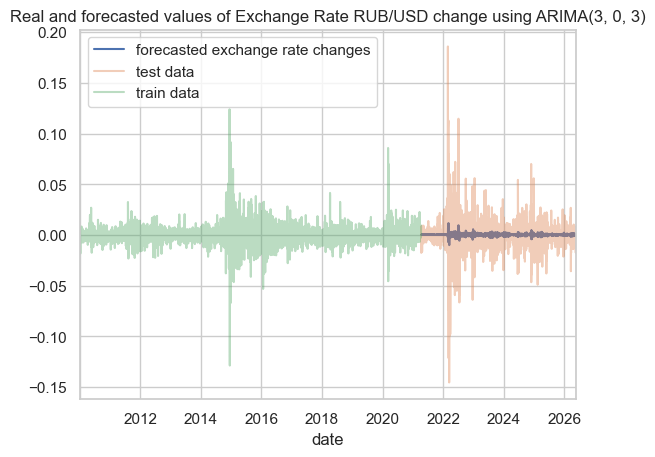

In [37]:
# ARIMA(3, 0, 3) for Exchange Rate
forcast_returns_ER_ARMA = rolling_forecast(currency, order=(3, 0, 3))
draw_forecast_graph(currency, forcast_returns_ER_ARMA, 'Exchange Rate RUB/USD change', order = (3, 0, 3))

In [38]:
currency_dm_test = dm_test(observed_currency_return, 
                           forcast_returns_ER_AR, 
                           forcast_returns_ER_ARMA)
print(f'Statistic is equal to {round(currency_dm_test[0], 2)}, p-value is equal to {round(currency_dm_test[1], 4)}')

Statistic is equal to 0.78, p-value is equal to 0.4344


We can't reject $H_0$  $\Rightarrow$ 2 models: AR(5) and ARIMA(3, 0, 3) are equally good. It can be seen from the graph that even taking latest variables for predictions forecasts are far from observed values. Clearly, that for AR(5) and ARMA(3, 3) there are not enough variation to fit real data.

(Diebold-Mariano statistic = 0.78, p-value = 0.434 — no significant difference in forecast accuracy.)

100%|██████████| 1282/1282 [21:13<00:00,  1.01it/s]


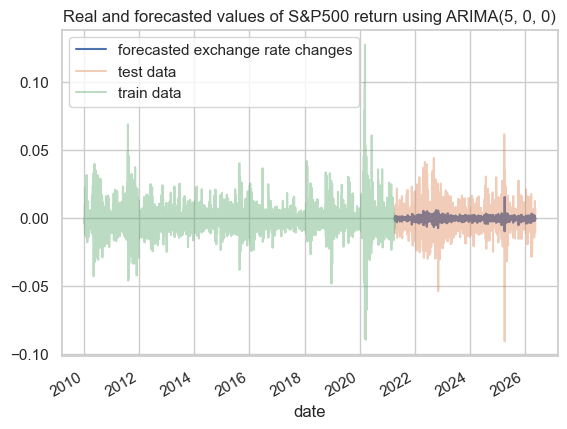

In [39]:
# AR(5) for S&P500 Returns
forcast_returns_SP500_AR = rolling_forecast(sp500, order=(5, 0, 0))
draw_forecast_graph(sp500, forcast_returns_SP500_AR, 'S&P500 return', order = (5, 0, 0))

100%|██████████| 1282/1282 [22:29<00:00,  1.05s/it]


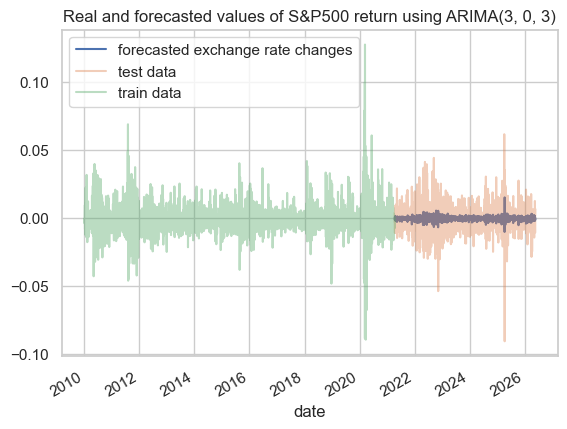

In [40]:
# ARIMA(3, 0, 3) for Exchange Rate
forcast_returns_SP500_ARMA = rolling_forecast(sp500, order=(3, 0, 3))
draw_forecast_graph(sp500, forcast_returns_SP500_ARMA, 'S&P500 return', order = (3, 0, 3))

In [41]:
sp500_dm_test = dm_test(observed_sp500_return, 
                           forcast_returns_SP500_AR, 
                           forcast_returns_SP500_ARMA)

print(f'Statistic is equal to {round(sp500_dm_test[0], 2)}, p-value is equal to {round(sp500_dm_test[1], 4)}')

Statistic is equal to -0.1, p-value is equal to 0.9214


There is still really weak variation in prediction (incomparably low with respect to observed values). Nevertheless, for S&P500 both models visually perform better than for exchange rate log returns due to more similar patterns. 
We can't reject $H_0$  $\Rightarrow$ 2 models: AR(5) and ARIMA(3, 0, 3) are equally good

(Diebold-Mariano statistic = -0.10, p-value = 0.921 — again, no significant difference.)

# d)

<a id='d'></a>

**Goal of this section.** Search for structural breaks in the **mean** and in the **variance** of log returns, using a grid search over candidate break dates (trimmed to the central 70% of the sample) with heteroskedasticity-and-autocorrelation-robust (Newey-West/HAC) standard errors — necessary given the volatility clustering documented above.

In [42]:
def structural_break_mean_search(data, trim = 0.15):
    lower_bound = int(trim * len(data))
    upper_bound = int((1-trim) * len(data))
    
    significant_dates = []
    
    for i in range(lower_bound, lower_bound):
        
        day = date.iloc[i-1]['date']
        data_with_dummy = data.copy(deep=True)
        data_with_dummy['T_dummy'] = (data['date'] >= date).astype(int)
        
        y = data_with_dummy['log_returns']
        X = sm.add_constant(data_with_dummy['T_dummy'])
        model = sm.OLS(y, X).fit()
        pval = model.pvalues['T_dummy']
        
        if pval <= 0.01:
            significant_dates.append(date)
        
    print(significant_dates)
    return significant_dates

In [43]:
def structural_break_variance_search(data, trim = 0.15):
    lower_bound = int(trim * len(data))
    upper_bound = int((1 - trim) * len(data))
    
    y = data['log_return']
    mu = y.mean()
    squared_residuals = (y - mu) ** 2
    
    significant_dates = []
    
    for i in range(lower_bound, upper_bound):
        
        date = data.iloc[i-1]['date']
        data_with_dummy = data.copy(deep=True)
        data_with_dummy['T_dummy'] = (data['date'] >= date).astype(int)
        
        X = sm.add_constant(data_with_dummy['T_dummy'])
        model = sm.OLS(squared_residuals, X).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
        pval = model.pvalues['T_dummy']
        
        if pval <= 0.01:
            significant_dates.append(date.date())
    
    return significant_dates

[]



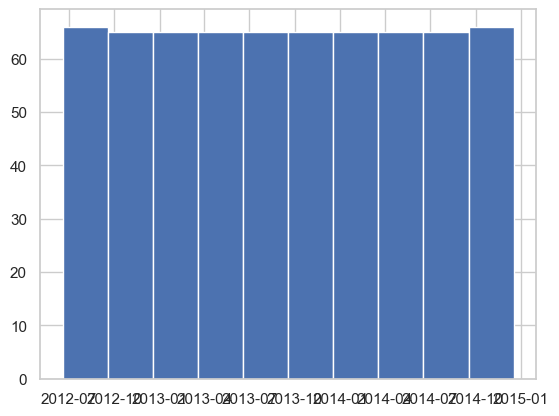

In [44]:
# RUB/USD
print(*structural_break_mean_search(currency), sep= ';')
pd.Series(structural_break_variance_search(currency)).hist()
plt.show()

[]



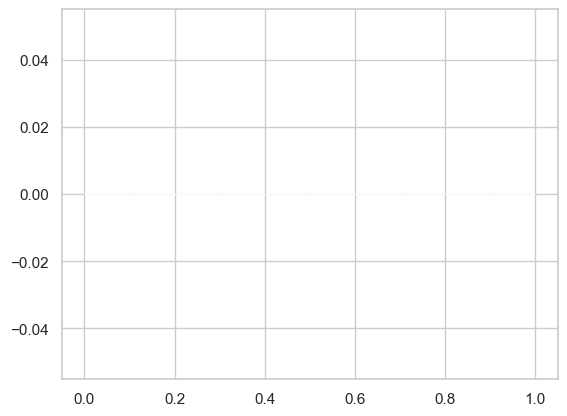

In [45]:
# S&P500
print(*structural_break_mean_search(sp500), sep= ';')
pd.Series(structural_break_variance_search(sp500)).hist()
plt.show()

An analysis of the structural gaps for logarithmic returns showed that no significant dates were found for either RUB/USD or S&P500 for the mean. When studying variance using robust Newey-West standard errors (HAC), which are necessary for correct testing due to strong autocorrelation of squares of residuals (volatility clustering). The results are different: no significant structural shifts in variance were detected for the S&P500, while quite a lot were found for RUB/USD such dates - all of them are before 2015. The distribution of these gaps by year is shown in the histogram.

The histogram above shows the yearly distribution of the significant variance-break dates found for RUB/USD; all of them cluster before 2015, a period that includes the end of the ruble's managed float and the 2014-2015 currency crisis.

# e)

<a id='e'></a>

**Goal of this section.** Test for **Granger causality** between the log price of RUB/USD and the log price of the S&P 500, in both directions, at lags 1 through 5.

In [46]:
df = currency[['log_price']].join(sp500[['log_price']],
                                  how='inner',
                                  lsuffix='_fx',
                                  rsuffix='_sp')

In [47]:
results_fx_sp = grangercausalitytests(df[['log_price_sp', 'log_price_fx']],
                      maxlag=5)

results_sp_fx = grangercausalitytests(df[['log_price_fx', 'log_price_sp']],
                      maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=3.2243  , p=0.0726  , df_denom=4115, df_num=1
ssr based chi2 test:   chi2=3.2266  , p=0.0724  , df=1
likelihood ratio test: chi2=3.2254  , p=0.0725  , df=1
parameter F test:         F=3.2243  , p=0.0726  , df_denom=4115, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.7285  , p=0.1777  , df_denom=4112, df_num=2
ssr based chi2 test:   chi2=3.4612  , p=0.1772  , df=2
likelihood ratio test: chi2=3.4597  , p=0.1773  , df=2
parameter F test:         F=1.7285  , p=0.1777  , df_denom=4112, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.6368  , p=0.0480  , df_denom=4109, df_num=3
ssr based chi2 test:   chi2=7.9237  , p=0.0476  , df=3
likelihood ratio test: chi2=7.9161  , p=0.0478  , df=3
parameter F test:         F=2.6368  , p=0.0480  , df_denom=4109, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=2.6314  , p=0.

In [48]:
table_fx_sp = []
for lag in range(1, 6):

    ftest = results_fx_sp[lag][0]['ssr_ftest']

    table_fx_sp.append({'lag': lag,
                        'F-stat': round(ftest[0], 4),
                        'p-value': round(ftest[1], 4)})

table_fx_sp = pd.DataFrame(table_fx_sp)

print(table_fx_sp)

   lag  F-stat  p-value
0    1  3.2243   0.0726
1    2  1.7285   0.1777
2    3  2.6368   0.0480
3    4  2.6314   0.0326
4    5  2.1483   0.0570


In [49]:
table_sp_fx = []

for lag in range(1, 6):

    ftest = results_sp_fx[lag][0]['ssr_ftest']

    table_sp_fx.append({'lag': lag,
                        'F-stat': round(ftest[0], 4),
                        'p-value': round(ftest[1], 4)})

table_sp_fx = pd.DataFrame(table_sp_fx)

print(table_sp_fx)

   lag  F-stat  p-value
0    1  3.1848   0.0744
1    2  1.8746   0.1535
2    3  1.1895   0.3121
3    4  0.9637   0.4261
4    5  0.7957   0.5526


The Granger causality test provides limited evidence that exchange rates Granger-cause S&P500 prices at lag lengths 3 and 4. No evidence is found that S&P500 prices Granger-cause exchange rates.

**FX → S&P 500** (does the exchange rate help predict the index?): F-statistics are only significant at lags 3 and 4 (F = 2.64, p = 0.048 and F = 2.63, p = 0.033 respectively); lags 1, 2 and 5 are not significant at 5%.

**S&P 500 → FX** (does the index help predict the exchange rate?): none of the five lags are significant (all p-values > 0.15).

Overall this is **weak, lag-specific evidence** of predictability from FX to equities and no evidence in the reverse direction — it should not be over-interpreted as a robust or economically large effect.

# f)

<a id='f'></a>

**Goal of this section.** Assess whether RUB/USD and S&P 500 (in log-price levels) are **cointegrated**, i.e. share a stable long-run linear relationship despite each series individually being non-stationary. The section proceeds in three steps: (i) a qualitative discussion of whether cointegration is theoretically plausible, (ii) a formal Johansen test after selecting the VAR lag order, and (iii) a Dynamic OLS (DOLS) regression as a robustness check.

## i)

Although both variables are likely nonstationary, there is no strong theoretical reason to expect a stable long-run equilibrium relationship between them. Fluctuations of S&P500 are mostly caused by local market events, while movements of RUB/USD are also dependent on Russian market. These factors will likely make changes in American index and exchnage rate different

## ii)

In [50]:
data = df[['log_price_fx', 'log_price_sp']]

In [51]:
model = VAR(data)

lag_selection = model.select_order(maxlags=10)

print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -4.853      -4.850    0.007802      -4.852
1       -17.67      -17.66   2.117e-08      -17.67
2       -17.68     -17.67*   2.092e-08      -17.68
3       -17.69      -17.66   2.086e-08      -17.68
4       -17.69      -17.66   2.086e-08      -17.68
5       -17.69      -17.65   2.083e-08      -17.68
6       -17.69      -17.65   2.083e-08      -17.67
7       -17.69      -17.64   2.077e-08      -17.67
8       -17.69      -17.64   2.069e-08      -17.67
9       -17.70      -17.64   2.052e-08      -17.68
10     -17.71*      -17.64  2.041e-08*     -17.68*
--------------------------------------------------


BIC selects a VAR(2) specification. Therefore, the Johansen maximum eigenvalue test is implemented with one lagged difference term.

The lag-selection table above reports AIC, BIC, FPE and HQIC across candidate lag orders; BIC (the most parsimonious criterion) selects 2 lags for the level VAR, hence 1 lag for the VECM/Johansen specification in first differences.

In [52]:
johansen_test = coint_johansen(data,
                               det_order=0,
                               k_ar_diff=1)

In [53]:
johansen_test.max_eig_stat

array([8.15789931, 1.37131195])

In [54]:
johansen_test.max_eig_stat_crit_vals

array([[12.2971, 14.2639, 18.52  ],
       [ 2.7055,  3.8415,  6.6349]])

The Johansen maximum eigenvalue test fails to reject the null hypothesis of no cointegration. Specifically, the test statistic for the null hypothesis (r=0) is 8.16, which is below the 5% critical value of 14.26. Therefore, there is no evidence of a long-run equilibrium relationship between the logarithmic exchange rates and logarithmic S&P500 prices.

For completeness: the max-eigenvalue statistic for `r ≤ 1` is 1.37, far below its 5% critical value of 3.84, so a second cointegrating relationship is also ruled out. Both eigenvalue tests therefore agree that **r = 0** — no cointegrating vector.

## iii)

In [55]:
y = data['log_price_sp']
x = data['log_price_fx']
dx = x.diff()
p = 30


In [56]:
dols_data = pd.DataFrame({'y': y,
                          'x': x})

for i in range(-p, p + 1):
    if i < 0:
        dols_data[f'dx_lag_{abs(i)}'] = dx.shift(abs(i))

    elif i > 0:
        dols_data[f'dx_lead_{i}'] = dx.shift(-i)
    
dols_data = dols_data.dropna()

In [57]:
T = len(dols_data)

hac_lags = int(0.75 * (T ** (1/3)))

In [58]:
Y = dols_data['y']

X = dols_data.drop(columns='y')

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit(cov_type='HAC',
                         cov_kwds={'maxlags': hac_lags})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     40.10
Date:                Sat, 13 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:25:43   Log-Likelihood:                 588.08
No. Observations:                4058   AIC:                            -1052.
Df Residuals:                    3996   BIC:                            -661.0
Df Model:                          61                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.6608      0.096    132.218      0.0

Although the estimated cointegrating coefficient may appear statistically significant, the previous Johansen maximum eigenvalue test provided no evidence of cointegration between the logarithmic exchange rates and logarithmic S&P500 prices. Therefore, the economic interpretation of the DOLS regression is limited, since DOLS is intended for variables that share a stable long-run equilibrium relationship.

The DOLS regression fits very well in a statistical sense (R² = 0.834), but a high R² between two trending series with no cointegrating relationship is a textbook symptom of a **spurious regression** — exactly the scenario the earlier Johansen test warns about, which is why the coefficient is not given a structural, long-run interpretation here.

---

## Conclusion<a id='conclusion'></a>

**Univariate dynamics (a, b).** Both RUB/USD and S&P 500 log prices behave like unit-root (random-walk-type) processes, while their log returns are stationary. In both cases log returns retain (i) a small amount of linear structure, best captured by a low-order ARMA model (ARMA(2,2) for FX, the richer ARMA(4,4) for equities), and (ii) strong, highly persistent conditional heteroskedasticity, best captured by GARCH (GARCH(1,2) for FX, GARCH(3,1) for equities).

**Forecasting (c).** Despite the significant in-sample ARMA structure, neither AR(5) nor ARMA(3,3) meaningfully outperforms the other out-of-sample (Diebold-Mariano tests fail to reject equal accuracy for both series), and both models' point forecasts show far less variation than the actually observed returns — a standard finding for short-horizon financial return forecasting, where in-sample predictability rarely translates into economically useful out-of-sample forecasts.

**Structural breaks (d).** No significant break in the *mean* of log returns is found for either series. In *variance*, RUB/USD shows several significant HAC-robust break dates, all clustered before 2015 (consistent with the 2014-2015 ruble crisis), while S&P 500 shows none.

**Granger causality (e).** There is weak, lag-specific evidence that RUB/USD log prices Granger-cause S&P 500 log prices (significant only at lags 3-4), and no evidence of causality in the opposite direction.

**Cointegration (f).** Economic reasoning, the Johansen trace/max-eigenvalue test, and the DOLS robustness check all point to the **same conclusion**: RUB/USD and S&P 500 log prices are **not cointegrated**. The seemingly strong DOLS fit is best read as a spurious regression rather than evidence of a genuine long-run equilibrium.

### Overall takeaway
The RUB/USD exchange rate and the S&P 500 index each display the classic stylized facts of daily financial series — a non-stationary price level, a stationary but weakly predictable return, and strongly persistent volatility clustering — but there is no strong evidence of a stable long-run link, or of strong bidirectional short-run predictability, between the two markets over this sample.
